# 09. Weather Feature Modeling

This notebook tests whether calendar and weather context features improve lotto prediction beyond the existing temporal baseline features.

Comparison strategy:

- `base`: existing temporal frequency + gap features
- `base_plus_calendar`: base + calendar context derived from draw date
- `base_plus_calendar_weather`: base + calendar + weather context
- `calendar_weather_only`: context-only reference model

The main goal is not to claim strong predictability, but to measure incremental value from contextual variables under the same time-based split.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
    if (candidate / "app" / "src").exists() and (candidate / "app" / "data").exists():
        PROJECT_ROOT = candidate / "app"
        break

if PROJECT_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/workspace')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import PROCESSED_LOTTO_FILE, WEATHER_CONTEXT_FILE
from src.features.build_features import build_feature_dataset
from src.features.temporal_features import align_features_and_labels, time_based_train_test_split
from src.models.train_baseline import build_logistic_regression_model
from src.models.model_suite import LABEL_COLS, NUMBER_COLS, evaluate_probability_model
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

## Configuration

In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
BACKTEST_INITIAL_TRAIN_SIZE = 600
BACKTEST_TEST_SIZE = 30
BACKTEST_STEP_SIZE = 30
MAX_BACKTEST_FOLDS = 12  # keep this notebook reasonably fast


## Load Base Datasets

In [4]:
feature_df = build_feature_dataset(window=WINDOW)
clean_df = pd.read_csv(PROCESSED_LOTTO_FILE, low_memory=False)
weather_df = pd.read_csv(WEATHER_CONTEXT_FILE, low_memory=False)

weather_df["draw_date"] = pd.to_datetime(weather_df["draw_date"], errors="coerce")
weather_df["draw_datetime_used"] = pd.to_datetime(weather_df["draw_datetime_used"], errors="coerce")

feature_df.shape, clean_df.shape, weather_df.shape

((1197, 90), (1217, 18), (1217, 24))

## Build Labels and Base Feature Matrix

In [5]:
label_df = pd.DataFrame(0, index=clean_df.index, columns=LABEL_COLS)
for i in range(len(clean_df)):
    nums = clean_df.loc[i, NUMBER_COLS].tolist()
    for num in nums:
        label_df.loc[i, f"y_{num}"] = 1

X_base, y = align_features_and_labels(feature_df, label_df, window=WINDOW)
target_rounds = clean_df.loc[WINDOW:, "round"].reset_index(drop=True)

X_base.shape, y.shape, target_rounds.shape

((1197, 90), (1197, 45), (1197,))

## Calendar and Weather Feature Blocks

In [6]:
calendar_weather = weather_df.copy()
calendar_weather["month"] = calendar_weather["draw_date"].dt.month
calendar_weather["year"] = calendar_weather["draw_date"].dt.year
calendar_weather["day_of_month"] = calendar_weather["draw_date"].dt.day
calendar_weather["season"] = pd.Categorical(
    np.select(
        [calendar_weather["month"].isin([12,1,2]), calendar_weather["month"].isin([3,4,5]), calendar_weather["month"].isin([6,7,8])],
        ["winter", "spring", "summer"],
        default="autumn",
    ),
    categories=["spring", "summer", "autumn", "winter"],
)

for col in ["temp_at_draw", "humidity_at_draw", "wind_at_draw", "pressure_at_draw", "precip_1h", "precip_6h", "precip_24h", "snow_at_draw"]:
    if col in calendar_weather.columns:
        calendar_weather[col] = pd.to_numeric(calendar_weather[col], errors="coerce")
        calendar_weather.loc[calendar_weather[col] < 0, col] = np.nan

calendar_weather["is_raining"] = calendar_weather["is_raining"].fillna(False).astype(int)
calendar_weather["is_snowing"] = calendar_weather["is_snowing"].fillna(False).astype(int)
calendar_weather["month_sin"] = np.sin(2 * np.pi * calendar_weather["month"] / 12)
calendar_weather["month_cos"] = np.cos(2 * np.pi * calendar_weather["month"] / 12)
calendar_weather["day_sin"] = np.sin(2 * np.pi * calendar_weather["day_of_month"] / 31)
calendar_weather["day_cos"] = np.cos(2 * np.pi * calendar_weather["day_of_month"] / 31)

calendar_cols = ["month_sin", "month_cos", "day_sin", "day_cos", "year"]
weather_cols = ["temp_at_draw", "humidity_at_draw", "wind_at_draw", "pressure_at_draw", "precip_1h", "precip_6h", "precip_24h", "is_raining", "is_snowing"]

calendar_weather = pd.concat([
    calendar_weather[["round"] + calendar_cols + weather_cols],
    pd.get_dummies(calendar_weather[["season"]], prefix="season", dtype=float),
    pd.get_dummies(calendar_weather[["temp_bin", "humidity_bin"]], dummy_na=True, dtype=float),
], axis=1)

calendar_weather.head()

,round,month_sin,month_cos,day_sin,day_cos,year,temp_at_draw,humidity_at_draw,wind_at_draw,pressure_at_draw,precip_1h,precip_6h,precip_24h,is_raining,is_snowing,season_spring,season_summer,season_autumn,season_winter,temp_bin_cold,temp_bin_freezing,temp_bin_hot,temp_bin_mild,temp_bin_warm,temp_bin_nan,humidity_bin_dry,humidity_bin_humid,humidity_bin_moderate,humidity_bin_very_humid,humidity_bin_nan
0,1,-2.449294e-16,1.000000,0.988468,0.151428,2002,5.1,55.0,3.5,1015.5,0.0,0.0,0.0,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,-2.449294e-16,1.000000,0.299363,-0.954139,2002,2.3,60.0,2.0,1021.5,0.0,0.0,0.0,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,-2.449294e-16,1.000000,-0.897805,-0.440394,2002,6.8,62.0,3.5,1015.2,0.0,0.0,0.0,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,-2.449294e-16,1.000000,-0.571268,0.820763,2002,0.0,64.0,4.4,1011.4,0.0,0.0,0.0,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5,5.000000e-01,0.866025,0.724793,0.688967,2003,NaN,59.0,3.8,1014.8,0.0,0.0,0.0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Align Context Features to Target Rounds

In [7]:
context_df = pd.DataFrame({"round": target_rounds})
context_df = context_df.merge(calendar_weather, on="round", how="left")

for col in context_df.columns:
    if col == "round":
        continue
    if context_df[col].dtype.kind in "biufc":
        context_df[col] = context_df[col].fillna(context_df[col].median() if context_df[col].notna().any() else 0)
    else:
        context_df[col] = context_df[col].fillna(0)

calendar_feature_cols = [col for col in context_df.columns if col in calendar_cols or col.startswith("season_")]
weather_feature_cols = [col for col in context_df.columns if col in weather_cols or col.startswith("temp_bin_") or col.startswith("humidity_bin_")]

X_calendar = context_df[calendar_feature_cols].reset_index(drop=True)
X_weather = context_df[weather_feature_cols].reset_index(drop=True)

X_feature_sets = {
    "base": X_base.reset_index(drop=True),
    "base_plus_calendar": pd.concat([X_base.reset_index(drop=True), X_calendar], axis=1),
    "base_plus_calendar_weather": pd.concat([X_base.reset_index(drop=True), X_calendar, X_weather], axis=1),
    "calendar_weather_only": pd.concat([X_calendar, X_weather], axis=1),
}

{k: v.shape for k, v in X_feature_sets.items()}

{'base': (1197, 90),
 'base_plus_calendar': (1197, 99),
 'base_plus_calendar_weather': (1197, 119),
 'calendar_weather_only': (1197, 29)}

## Holdout Comparison

In [8]:
def evaluate_logistic_feature_set(X_frame, y_frame, feature_set_name):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=TEST_RATIO)
    model = build_logistic_regression_model(random_seed=RANDOM_SEED)
    model.fit(split["X_train"], split["y_train"])
    result = evaluate_probability_model(feature_set_name, model, split["X_test"], split["y_test"])
    row = {
        "feature_set": feature_set_name,
        "subset_accuracy": result["subset_accuracy"],
        "number_level_accuracy": result["number_level_accuracy"],
        "avg_hit": result["avg_hit"],
        "hit_std": result["hit_std"],
        "n_train_rows": len(split["X_train"]),
        "n_test_rows": len(split["X_test"]),
    }
    return row

holdout_rows = []
for feature_set_name, X_frame in X_feature_sets.items():
    holdout_rows.append(evaluate_logistic_feature_set(X_frame, y.reset_index(drop=True), feature_set_name))

holdout_feature_summary = pd.DataFrame(holdout_rows).sort_values("avg_hit", ascending=False).reset_index(drop=True)
holdout_feature_summary

,feature_set,subset_accuracy,number_level_accuracy,avg_hit,hit_std,n_train_rows,n_test_rows
0,base,0.0,0.772037,0.870833,0.824105,957,240
1,base_plus_calendar,0.0,0.771481,0.858333,0.824579,957,240
2,base_plus_calendar_weather,0.0,0.770926,0.845833,0.799208,957,240
3,calendar_weather_only,0.0,0.770185,0.829167,0.826629,957,240


/tmp/ipykernel_176/3752211619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holdout_feature_summary, x="feature_set", y="avg_hit", palette="viridis", ax=ax)


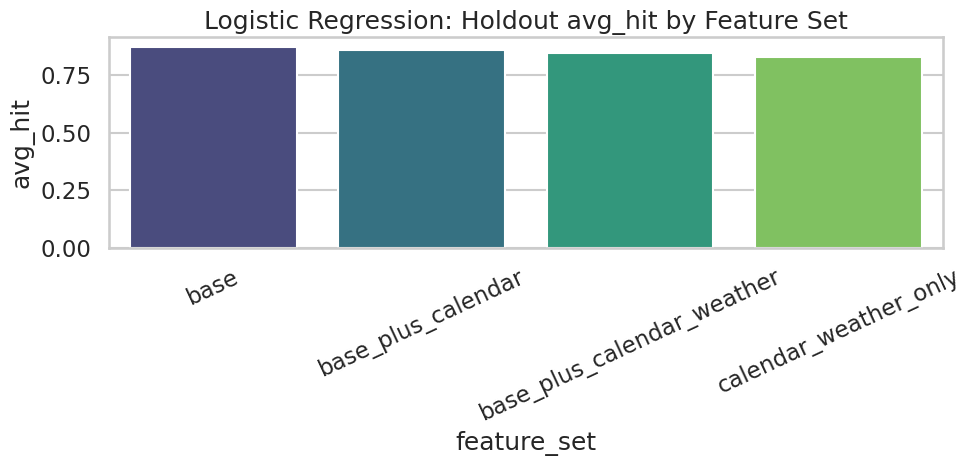

In [9]:
fig_feature_holdout, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=holdout_feature_summary, x="feature_set", y="avg_hit", palette="viridis", ax=ax)
ax.set_title("Logistic Regression: Holdout avg_hit by Feature Set")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Rolling Backtest Comparison

In [10]:
def run_feature_backtest(X_frame, y_frame, feature_set_name):
    rows = []
    for fold_idx, train_end in enumerate(range(BACKTEST_INITIAL_TRAIN_SIZE, len(X_frame) - BACKTEST_TEST_SIZE + 1, BACKTEST_STEP_SIZE)):
        if MAX_BACKTEST_FOLDS is not None and fold_idx >= MAX_BACKTEST_FOLDS:
            break
        test_end = train_end + BACKTEST_TEST_SIZE
        X_train_fold = X_frame.iloc[:train_end].reset_index(drop=True)
        y_train_fold = y_frame.iloc[:train_end].reset_index(drop=True)
        X_test_fold = X_frame.iloc[train_end:test_end].reset_index(drop=True)
        y_test_fold = y_frame.iloc[train_end:test_end].reset_index(drop=True)
        model = build_logistic_regression_model(random_seed=RANDOM_SEED)
        model.fit(X_train_fold, y_train_fold)
        result = evaluate_probability_model(feature_set_name, model, X_test_fold, y_test_fold)
        rows.append({
            "fold": fold_idx,
            "feature_set": feature_set_name,
            "subset_accuracy": result["subset_accuracy"],
            "number_level_accuracy": result["number_level_accuracy"],
            "avg_hit": result["avg_hit"],
        })
    return pd.DataFrame(rows)

backtest_results = []
for feature_set_name, X_frame in X_feature_sets.items():
    backtest_results.append(run_feature_backtest(X_frame, y.reset_index(drop=True), feature_set_name))

backtest_feature_results = pd.concat(backtest_results, ignore_index=True)
backtest_feature_summary = backtest_feature_results.groupby("feature_set", as_index=False).agg(
    folds=("fold", "nunique"),
    mean_subset_accuracy=("subset_accuracy", "mean"),
    mean_number_level_accuracy=("number_level_accuracy", "mean"),
    mean_avg_hit=("avg_hit", "mean"),
    std_avg_hit=("avg_hit", "std"),
).sort_values("mean_avg_hit", ascending=False).reset_index(drop=True)

backtest_feature_summary

,feature_set,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,std_avg_hit
0,base,12,0.0,0.770617,0.838889,0.142725
1,base_plus_calendar_weather,12,0.0,0.769506,0.813889,0.136669
2,base_plus_calendar,12,0.0,0.768642,0.794444,0.131682
3,calendar_weather_only,12,0.0,0.767654,0.772222,0.139141


/tmp/ipykernel_176/83556522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=backtest_feature_summary, x="feature_set", y="mean_avg_hit", palette="mako", ax=ax)


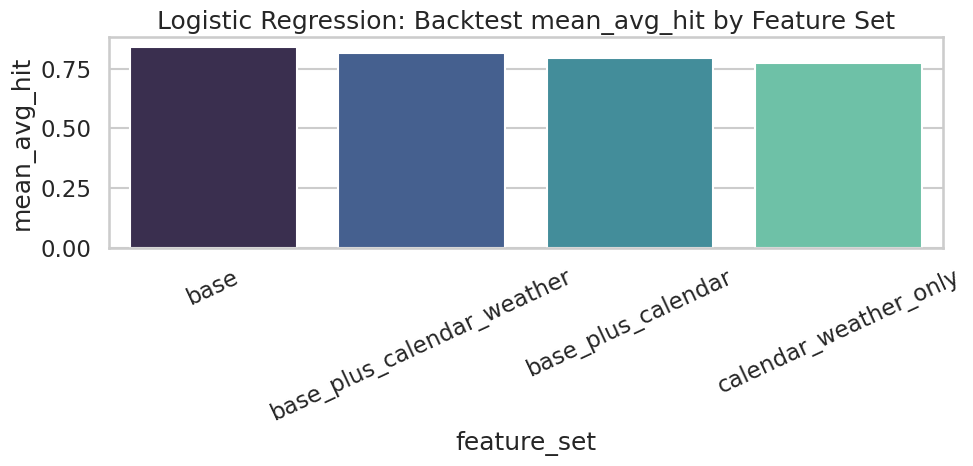

In [11]:
fig_feature_backtest, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=backtest_feature_summary, x="feature_set", y="mean_avg_hit", palette="mako", ax=ax)
ax.set_title("Logistic Regression: Backtest mean_avg_hit by Feature Set")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

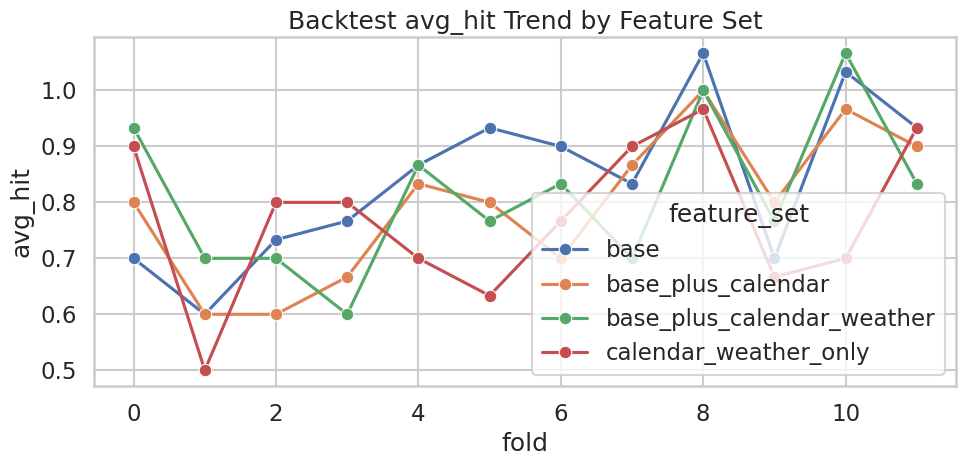

In [12]:
fig_feature_trend, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=backtest_feature_results, x="fold", y="avg_hit", hue="feature_set", marker="o", ax=ax)
ax.set_title("Backtest avg_hit Trend by Feature Set")
plt.tight_layout()
plt.show()

## Interpretation Notes

In [13]:
comparison_cols = [
    "feature_set",
    "avg_hit",
    "number_level_accuracy",
]
holdout_feature_summary[comparison_cols]

,feature_set,avg_hit,number_level_accuracy
0,base,0.870833,0.772037
1,base_plus_calendar,0.858333,0.771481
2,base_plus_calendar_weather,0.845833,0.770926
3,calendar_weather_only,0.829167,0.770185


Use the results with a conservative interpretation:

- if `base_plus_calendar_weather` is only marginally better than `base`, the added context may be interesting but not strongly predictive
- if `calendar_weather_only` performs much worse than `base`, then context is acting as a weak auxiliary signal rather than a standalone predictor
- backtest results matter more than a single holdout split when judging robustness


## Report Export

In [14]:
save_report_figure(fig_feature_holdout, "fig_26_weather_feature_holdout_comparison.png")
save_report_figure(fig_feature_backtest, "fig_27_weather_feature_backtest_comparison.png")
save_report_figure(fig_feature_trend, "fig_28_weather_feature_backtest_trend.png")

save_report_table(holdout_feature_summary, "table_20_weather_feature_holdout_summary.csv")
save_report_table(backtest_feature_summary, "table_21_weather_feature_backtest_summary.csv")
save_report_table(backtest_feature_results, "table_22_weather_feature_backtest_results.csv")
print("Saved weather feature modeling report artifacts.")

Saved weather feature modeling report artifacts.
